<a href="https://colab.research.google.com/github/RKumarAccount/LR-Classification-with-AUC-ROC/blob/main/LR_Classification_with_AUC_%26_ROC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#dataset=pd.read_csv(r'C:\Users\RanjitKumar\Desktop\7pm batch notes\logit classification.csv')
dataset=pd.read_csv(r'/content/logit classification.csv')

X=dataset.iloc[:,[2,3]].values
y=dataset.iloc[:,-1].values


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=.20,random_state=0)


from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)
#X_test=sc.fit_transform(X_test)# change to fit_transform 87

from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression(penalty='l2',solver='newton-cg',max_iter=300)
classifier.fit(X_train, y_train)

y_pred=classifier.predict(X_test)

from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, y_pred)
#print("Confusion Matrix: ", cm)# change to fit_transform- Same

from sklearn.metrics import accuracy_score
ac=accuracy_score(y_test, y_pred)
print("Model Accuracy: ", ac) # 89 # change to fit_transform 87


from sklearn.metrics import classification_report
cr=classification_report(y_test, y_pred)
print("Report: ", cr) # 89 # change to fit_transform 87


bias=classifier.score(X_train, y_train)
print("Bias: ", bias)#82

variance=classifier.score(X_test, y_test)
print("Variance: ", variance)#89

Model Accuracy:  0.925
Report:                precision    recall  f1-score   support

           0       0.92      0.98      0.95        58
           1       0.94      0.77      0.85        22

    accuracy                           0.93        80
   macro avg       0.93      0.88      0.90        80
weighted avg       0.93      0.93      0.92        80

Bias:  0.821875
Variance:  0.925


In [5]:
dataset1=pd.read_csv(r'/content/Future prediction1.csv')

d2=dataset1.copy()
print(d2)

dataset1=dataset1.iloc[:,[2,3]].values

from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
M=sc.fit_transform(dataset1)
print(M)

y_pred1=pd.DataFrame()
d2['y_pred1']=classifier.predict(M)
print(d2)

    User ID  Gender  Age  EstimatedSalary
0  15724611    Male   45            60000
1  15725621  Female   79            64000
2  15725622    Male   23            78000
3  15720611  Female   34            45000
4  15588044    Male   29            76000
5  15746039  Female   70            89000
6  15704887    Male   86           120000
7  15746009  Female   46            23000
8  15876009    Male   32            70000
9  15886009  Female  100            90000
[[-0.36494467 -0.4578622 ]
 [ 0.95506797 -0.29860578]
 [-1.2190705   0.25879168]
 [-0.79200759 -1.05507376]
 [-0.98612709  0.17916347]
 [ 0.60565286  0.69674682]
 [ 1.22683528  1.93098404]
 [-0.32612077 -1.93098404]
 [-0.86965539 -0.05972116]
 [ 1.7703699   0.73656092]]
    User ID  Gender  Age  EstimatedSalary  y_pred1
0  15724611    Male   45            60000        0
1  15725621  Female   79            64000        1
2  15725622    Male   23            78000        0
3  15720611  Female   34            45000        0
4  15588044 

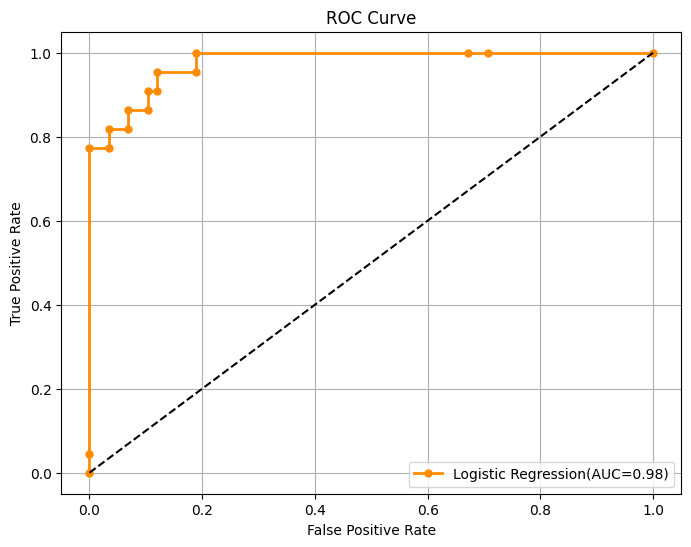

In [11]:
from sklearn.metrics import roc_auc_score,roc_curve

y_pred_prob=classifier.predict_proba(X_test)[:,1]

auc_score=roc_auc_score(y_test,y_pred_prob)
auc_score

fpr,tpr,thresold=roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f'Logistic Regression(AUC={auc_score:.2f})', color='darkorange', lw=2, marker='o', markersize=5)
#plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.2f})')

plt.plot([0,1],[0,1],'k--')#Randome classifier Line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()